In [1]:
# Run this cell.
from datascience import *
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")
import warnings
warnings.filterwarnings('ignore')

<img src="https://github.com/data-6-berkeley/materials-fa24/blob/main/hw/hw03/data6.png?raw=true" style="width: 15%; float: right; padding: 1%; margin-right: 2%;"/>

# Bickel Case Study

**Goals:**
- Load and inspect real admissions data  
- Compare overall and department-level admission rates by gender  
- Visualize Simpson’s Paradox  

**Dataset Source:** The [dataset](https://discovery.cs.illinois.edu/dataset/berkeley/) used in this notebook is a cleaned version of the original UC Berkeley 1973 graduate admissions data, processed by the University of Illinois at Urbana-Champaign.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## [Discussion] Data Talk

<div class="alert alert-info">

1. **What do you notice?**

2. **What do you wonder?**

3. **What story does this tell, especially about the community this data may impact?**

</div>

| Group   | Applicants | Admitted | Men Applicants | Men Admitted                                | Women Applicants | Women Admitted |
|---------|------------|----------|----------------|----------------------------------------------|------------------|----------------|
| **Total** | 12,763 | 41%   | 8,442       | <span style="color:green"><b>44%</b></span> | 4,321         | **35%**          |

| Dept | All Applicants | All Admitted | Men Applicants | Men Admitted | Women Applicants | Women Admitted |
|------|----------------|--------------|----------------|--------------|------------------|----------------|
| A    | 1,246            | 73%          | <span style="color:blue"><b>**1,138**</b></span> | 72%          | 108              | <span style="color:green"><b>82%</b></span> |
| B    | 585            | 63%          | <span style="color:blue"><b>**560**</b></span> | 63%          | 25               | <span style="color:green"><b>68%</b></span> |
| C    | 918            | 35%          | 325            | <span style="color:green"><b>37%</b></span> | <span style="color:blue"><b>**593**</b></span> | 34% |
| D    | 792            | 34%          | <span style="color:blue"><b>417</b></span> | 33%          | 375              | <span style="color:green"><b>35%</b></span> |
| E    | 584            | 25%          | 191            | <span style="color:green"><b>28%</b></span> | <span style="color:blue"><b>**393**</b></span> | 24% |
| F    | 714            | 7%           | <span style="color:blue"><b>373</b></span> | 6%           | 341              | <span style="color:green"><b>7%</b></span> |
| **Total** | **4,839**      | **43%**       | **3,004**      | <span style="color:green"><b>**50%**</b></span> | **1,835**        | **30%**        |

<hr style="border: 1px solid #fdb515;" />

## 1973 UC Berkeley Graduate Admissions

In [2]:
# Run this cell to load data from CSV
cal_data = Table.read_table('UCBerkeley1973_Admission.csv')
cal_data.show(5)

Year,Major,Gender,Admission
1973,C,F,Rejected
1973,B,M,Accepted
1973,Other,F,Accepted
1973,Other,M,Accepted
1973,Other,M,Rejected


### Question 1: 1973's Berkeley Admission Rate Calculations

Fill in the `...` with the given variables (e.g. `total_f`, `total_m`, `accepted_f`, or `accepted_m`) to compute the 1973 acceptance rates for women (`acceptance_rate_f`) and men(`acceptance_rate_m`).

**NOTE:** `/` can be used as a math division in Python

In [3]:
total_f = sum(cal_data.column("Gender") == "F") #total number of female applicants in the dataset
total_m = sum(cal_data.column("Gender") == "M") #total number of male applicants in the dataset
accepted_f = cal_data.where("Admission", "Accepted").where("Gender", "F").num_rows #number of female applicants who were accepted
accepted_m =  cal_data.where("Admission", "Accepted").where("Gender", "M").num_rows #number of male applicants who were accepted

#calculate the acceptance rate for female and male applicants
acceptance_rate_f = accepted_f / total_f #SOLUTION
acceptance_rate_m = accepted_m / total_m #SOLUTION
print("1973's Berkeley admission rate seems to be: female:", acceptance_rate_f * 100, "and male:", acceptance_rate_m * 100)

1973's Berkeley admission rate seems to be: female: 34.5753297848 and male: 44.2786069652


### [Tutorial] `.pivot` (Berkeley admissions)

The `pivot` method creates a two-way table showing the intersection of two columns.

`pivot(columns, rows, values=None, collect=None)`

- `columns`: unique values become the new column headers
- `rows`: unique values become the row labels
- if you do **not** pass `values` and `collect`, each cell is a **count of rows**

For this dataset:

- `columns='Admission'` gives columns like `Accepted` and `Rejected`
- `rows='Gender'` gives rows for `F` and `M`

So `cal_data.pivot('Admission', 'Gender')` answers:

> For each gender, how many applications were accepted vs rejected?

In [4]:
accepted_vs_rejected = cal_data.pivot('Admission', 'Gender')
accepted_vs_rejected

Gender,Accepted,Rejected
F,1494,2827
M,3738,4704


### Question 2: Build `num_applicants` for later

Using the `cal_data` table loaded earlier and the table method from the section above, update the code cell to create a table named `num_applicants` that shows the number of applicants for each **Major x Gender** combination.
Use the correct column names as strings.

Your final table should look like:

![Example num_applicants table](num_applicant_table_example.png)

We will reuse this exact `num_applicants` table later in the **Simpson’s Paradox Coding** section.

**IMPORTANT NOTE:** The string of the column names that you want to pass into as the arguements must have the exact match in capitalization, spelling, and space.

In [5]:
num_applicants = cal_data.pivot('Gender', 'Major') #SOLUTION
num_applicants

Major,F,M
A,108,1138
B,25,560
C,593,325
D,375,417
E,393,191
F,341,373
Other,2486,5438


<hr style="border: 1px solid #fdb515;" />

## [Discussion] Visualization Talk

<div class="alert alert-info">

1. **What do you notice?**

2. **What do you wonder?**

3. **What columns plotted what?** (Focus on axes)

</div>

### [Tutorial]`.barh` (Berkeley admissions)

Use `.barh` to make a **horizontal bar chart** or `.bar` to make a **vertical bar chart** from a table with categories.

`table.barh(category_column, optional_numeric_columns)` or `table.bar(category_column, optional_numeric_columns)` 

- first argument: the category labels (y-axis)
- if no numeric columns are specified, `barh` plots all numeric columns

For this notebook, `accepted_vs_rejected` has:
- category column: `Gender`
- numeric columns: `Accepted`, `Rejected`

So `accepted_vs_rejected.barh("Gender")` draws one horizontal bar for each gender, split by accepted vs rejected counts.

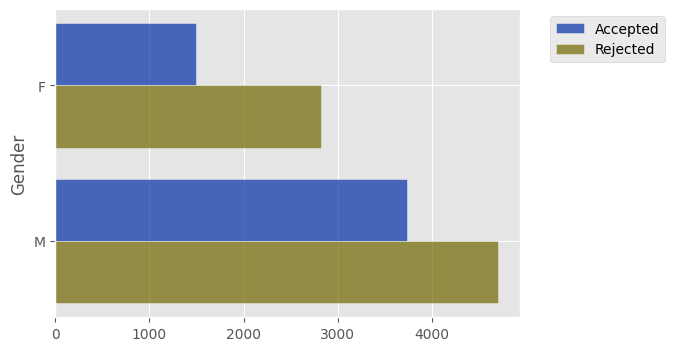

In [6]:
#run this cell to see the demo
accepted_vs_rejected.barh("Gender")

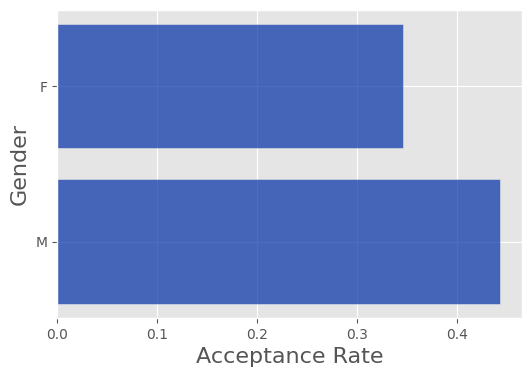

In [7]:
#run this cell to see the demo
admissions = cal_data.pivot('Admission', 'Gender').with_column("Acceptance Rate", make_array(acceptance_rate_f, acceptance_rate_m))
admissions.barh("Gender", "Acceptance Rate")

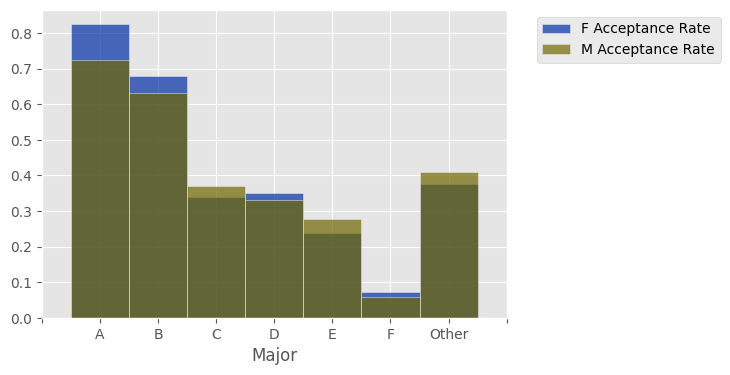

In [8]:
#run this cell to see the demo
admission_major = cal_data.pivot('Gender', 'Major', collect = lambda x: sum(x == 'Accepted') / len(x), values = 'Admission')
admission_major = admission_major.relabeled(['F', 'M'], ['F Acceptance Rate', 'M Acceptance Rate'])
admission_major.bar('Major', overlay = True)

<hr style="border: 1px solid #fdb515;" />

## Question 3: Simpson’s Paradox Coding

Instead of visualizing admission rates, let’s focus on the total number of admitted applicants. Modify the code using the `num_applicants` that you have created earlier in the `Data Talk` section to produce a **vertical bar chart** as shown below:

<img src="https://github.com/dubois-ctds/data6-nwdse-2025/blob/main/visualizations-workshop/barchart.png?raw=true" alt="Bar Chart"/>

Fill in `___` and `...` with the appropriate table method and the appropriate strings of column name as its parameter below. </br>

**HINT**: Reference the `Visualization Talk` section of this workshop from earlier in this notebook

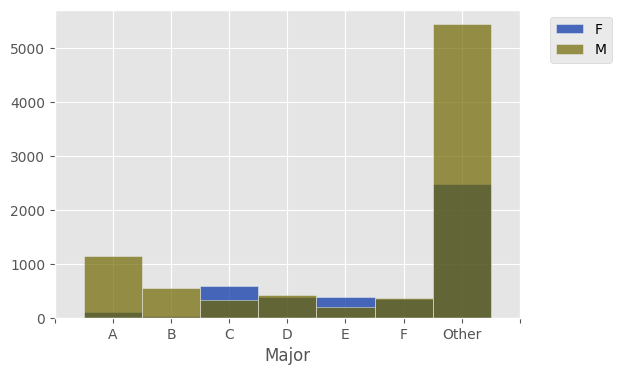

In [9]:
num_applicants.bar('Major') #SOLUTION

<hr style="border: 1px solid #fdb515;" />

## [Tutorial] Compare Percentages vs Applicant Counts

In the next cell, compute and plot percentages by major, then compare that result to your earlier `num_applicants` count table.

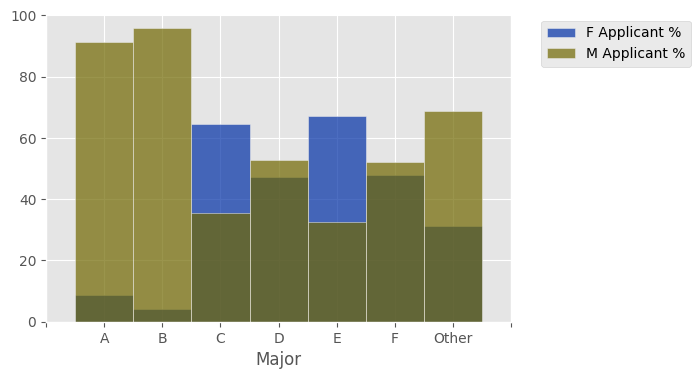

In [10]:
#run this cell to see the demo
# Count of applicants by Major x Gender
num_applicants = cal_data.pivot("Gender", "Major")

# Convert counts to within-major percentages
major_totals = (
    num_applicants.column("F")
    + num_applicants.column("M")
)
major_gender_pct = num_applicants.with_columns(
    "F Applicant %", 100 * num_applicants.column("F") / major_totals,
    "M Applicant %", 100 * num_applicants.column("M") / major_totals,
).select("Major", "F Applicant %", "M Applicant %")
major_gender_pct.bar("Major")